# Fertilizer Market Intelligence: Urea Price Analysis and Forecasting

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

In [2]:
df= pd.read_excel("CMO-Historical-Data-Monthly.xlsx", header= [4,5],sheet_name="Monthly Prices")

df.columns = [
    "Date" if i == 0 else " ".join(map(str, col)).strip()
    for i, col in enumerate(df.columns)
]

df["Date"] = df["Date"].str.replace("M", "-", regex=False)
df= df.replace("…", np.nan)
data= df.copy()

In [3]:
df.head(100)

,Date,"Crude oil, average ($/bbl)","Crude oil, Brent ($/bbl)","Crude oil, Dubai ($/bbl)","Crude oil, WTI ($/bbl)","Coal, Australian ($/mt)","Coal, South African ** ($/mt)","Natural gas, US ($/mmbtu)","Natural gas, Europe ($/mmbtu)","Liquefied natural gas, Japan ($/mmbtu)",...,Aluminum ($/mt),"Iron ore, cfr spot ($/dmtu)",Copper ($/mt),Lead ($/mt),Tin ($/mt),Nickel ($/mt),Zinc ($/mt),Gold ($/troy oz),Platinum ($/troy oz),Silver ($/troy oz)
0,1960-01,1.6,1.6,1.6,NaN,NaN,NaN,0.14,0.40,NaN,...,511,11.4,715,206,2180,1631,261,35,84,0.9
1,1960-02,1.6,1.6,1.6,NaN,NaN,NaN,0.14,0.40,NaN,...,511,11.4,728,204,2180,1631,245,35,84,0.9
2,1960-03,1.6,1.6,1.6,NaN,NaN,NaN,0.14,0.40,NaN,...,511,11.4,685,210,2174,1631,249,35,84,0.9
3,1960-04,1.6,1.6,1.6,NaN,NaN,NaN,0.14,0.40,NaN,...,511,11.4,723,214,2178,1631,255,35,84,0.9
4,1960-05,1.6,1.6,1.6,NaN,NaN,NaN,0.14,0.40,NaN,...,511,11.4,685,213,2163,1631,254,35,84,0.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1967-12,1.3,1.3,1.3,NaN,NaN,NaN,0.16,0.46,NaN,...,540,8.9,1324,222,3192,1936,266,35,115,2.1
96,1968-01,1.3,1.3,1.3,NaN,NaN,NaN,0.16,0.45,NaN,...,540,8.8,1409,218,3126,2075,263,36,114,2.0
97,1968-02,1.3,1.3,1.3,NaN,NaN,NaN,0.16,0.45,NaN,...,540,8.8,1720,228,3111,2075,260,36,112,1.9
98,1968-03,1.3,1.3,1.3,NaN,NaN,NaN,0.16,0.45,NaN,...,540,8.8,1701,234,3113,2075,258,37,112,2.2


In [4]:
data= data[["Date", "Wheat, US SRW ($/mt)", "Natural gas, Europe ($/mmbtu)", "Urea  ($/mt)"]]

data.columns = ["Date", "Wheat", "Natural_Gas_EU", "Urea"]

In [5]:
missing_rate = round(data.isna().mean()*100,2)

missing_rate

Date               0.00
Wheat             28.46
Natural_Gas_EU     0.00
Urea               0.00
dtype: float64

In [6]:
cleaned_df= data.dropna().copy()

## 1. Exploratory Data Analysis

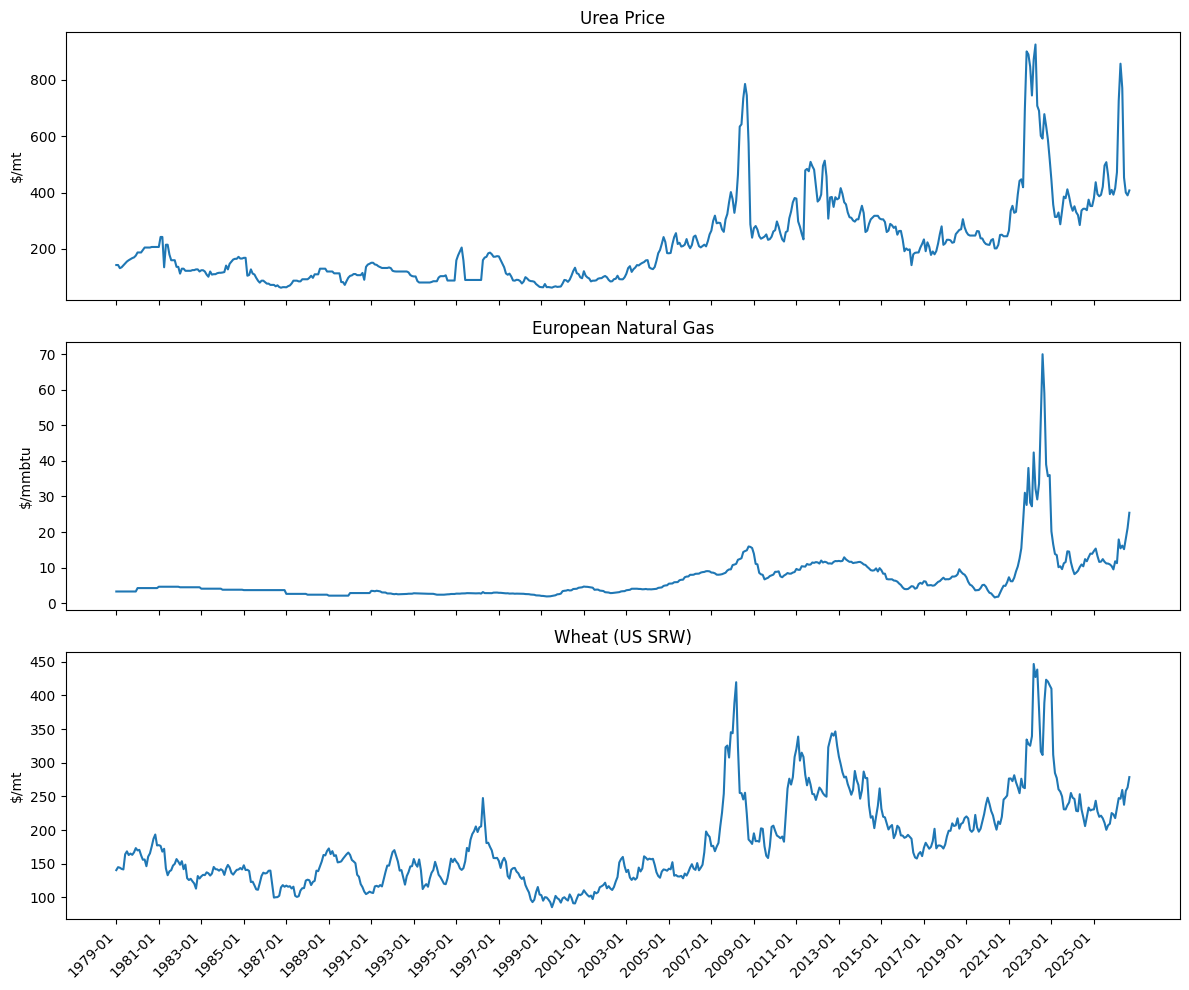

In [7]:
%matplotlib inline

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

x = range(len(cleaned_df))

axes[0].plot(x, cleaned_df["Urea"])
axes[0].set_title("Urea Price")
axes[0].set_ylabel("$/mt")

axes[1].plot(x, cleaned_df["Natural_Gas_EU"])
axes[1].set_title("European Natural Gas")
axes[1].set_ylabel("$/mmbtu")

axes[2].plot(x, cleaned_df["Wheat"])
axes[2].set_title("Wheat (US SRW)")
axes[2].set_ylabel("$/mt")

# Show annually
ticks = range(0, len(cleaned_df), 24)
axes[2].set_xticks(ticks)
axes[2].set_xticklabels(
    cleaned_df["Date"].iloc[::24],
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

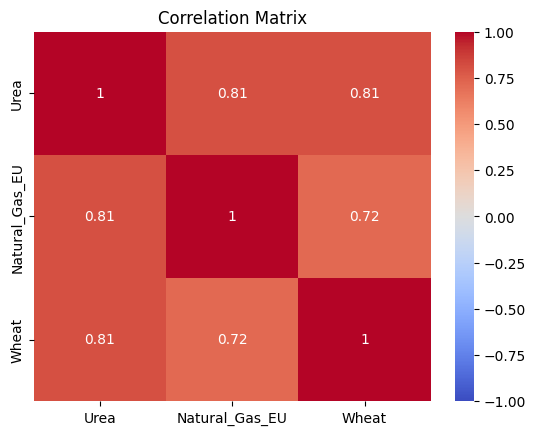

In [8]:

sns.heatmap(
    cleaned_df[["Urea", "Natural_Gas_EU", "Wheat"]].corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.show()

## 2. Lagged Relationship Analysis

In [9]:
def create_lags(df, columns, max_lag=7):
    df = df.copy()
    
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    
    for col in columns:
        for lag in range(1, max_lag + 1):
            df[f"{col}_Lag{lag}"] = df[col].shift(lag)
    
    return df

In [10]:
max_lag= 7
lag_df = create_lags(
    cleaned_df,
    columns=["Natural_Gas_EU", "Wheat"],
    max_lag= max_lag)

In [11]:
EU_gas_lags = {}
wheat_lags = {}

for lag in range(1, max_lag):
    EU_gas_lags[lag] = lag_df["Urea"].corr(
        lag_df[f"Natural_Gas_EU_Lag{lag}"]
    )
    
    wheat_lags[lag] = lag_df["Urea"].corr(
        lag_df[f"Wheat_Lag{lag}"]
    )

In [14]:
best_eu_gas_lag = max(EU_gas_lags, key=lambda x: abs(EU_gas_lags[x]))
best_wheat_lag = max(wheat_lags, key=lambda x: abs(wheat_lags[x]))

print(f"Best Natural Gas EU Lag: {best_eu_gas_lag} months ({EU_gas_lags[best_eu_gas_lag]:.3f})")
print(f"Best Wheat lag: {best_wheat_lag} months ({wheat_lags[best_wheat_lag]:.3f})")

Best Natural Gas EU Lag: 1 months (0.798)
Best Wheat lag: 1 months (0.805)


## 3. Short-Term Price-Change Analysis

In [15]:
lag_df["Urea_change"] = lag_df["Urea"].pct_change()
lag_df["Gas_change"] = lag_df["Natural_Gas_EU"].pct_change()
lag_df["Wheat_change"] = lag_df["Wheat"].pct_change()

In [16]:
for lag in range(1, max_lag):
    gas_corr = lag_df["Urea_change"].corr(
        lag_df["Gas_change"].shift(lag)
    )
    
    wheat_corr = lag_df["Urea_change"].corr(
        lag_df["Wheat_change"].shift(lag)
    )
    
    print(
        f"Lag {lag:2d} | "
        f"Gas: {gas_corr:.3f} | "
        f"Wheat: {wheat_corr:.3f}"
    )

Lag  1 | Gas: 0.161 | Wheat: 0.049
Lag  2 | Gas: 0.106 | Wheat: 0.051
Lag  3 | Gas: 0.013 | Wheat: -0.012
Lag  4 | Gas: -0.024 | Wheat: 0.113
Lag  5 | Gas: 0.026 | Wheat: 0.030
Lag  6 | Gas: 0.077 | Wheat: 0.040


- In short term, Neutral gas shows strongest association with subsequent urea price changes at 1 month lag.
- On the other hand, Wheat indicates only weak signal accross the tested lag.

## 4. Feature Engineering and Train/Test Split

In [17]:

lag_df = create_lags(
    lag_df,
    columns=["Urea"],
    max_lag= max_lag)

In [18]:
features = [
    "Urea_Lag1",
    "Natural_Gas_EU_Lag1",
    "Wheat_Lag1",
    "Wheat_Lag4"
]


model_df = lag_df[["Date", "Urea"] + features].dropna()

model_df = model_df.sort_values("Date").reset_index(drop=True)

split = int(len(model_df) * 0.8)

train = model_df.iloc[:split]
test = model_df.iloc[split:]

y_train = train["Urea"]
y_test = test["Urea"]

## 5. Model Comparison and Selection

In [20]:
feature_sets = {
    "Lag 1": [
        "Urea_Lag1",
        "Natural_Gas_EU_Lag1",
        "Wheat_Lag1"
    ],
    "Wheat Lag 4": [
        "Urea_Lag1",
        "Natural_Gas_EU_Lag1",
        "Wheat_Lag4"
    ]
}

results = {}


for name, features in feature_sets.items():

    X_train = train[features]
    X_test = test[features]


    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)

    results[f"Linear - {name}"] = {
        "MAE": mean_absolute_error(y_test, lr_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, lr_pred))
    }

    # XGBoost
    xgb = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        objective="reg:squarederror",
        random_state=42
    )

    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)

    results[f"XGBoost - {name}"] = {
        "MAE": mean_absolute_error(y_test, xgb_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_pred))
    }

In [26]:
results_df = results_df.sort_values(["MAE", "RMSE"])
results_df

,index,MAE,RMSE
0,Linear - Lag 1,38.209881,66.712230
2,Linear - Wheat Lag 4,38.673385,67.160082
1,XGBoost - Lag 1,64.503634,115.199703
3,XGBoost - Wheat Lag 4,73.990500,135.345342


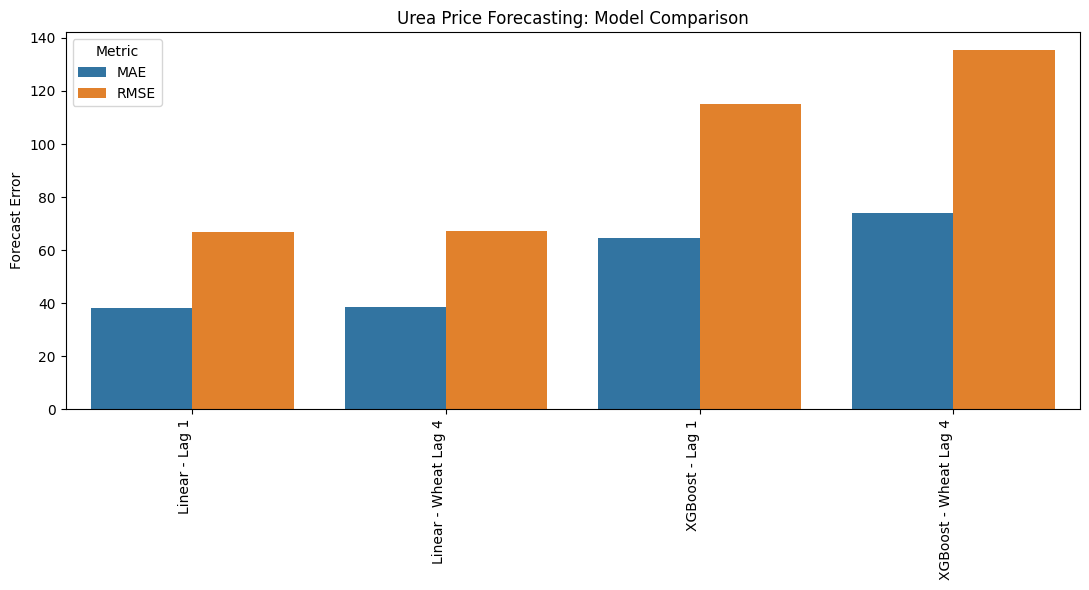

In [27]:

results_df = results_df.rename(columns={"index": "Model"})

plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE"],
    var_name="Metric",
    value_name="Error"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Error",
    hue="Metric"
)

plt.title("Urea Price Forecasting: Model Comparison")
plt.xlabel("")
plt.ylabel("Forecast Error")
plt.xticks(rotation=90, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

- The Lag 1 Linear Regression model provided the most accurate predictions among the tested feature-based models, with an MAE of 38.21 and RMSE of 66.71 

## 6. Final Forecast and Visualization

In [33]:
final_features = [
    "Urea_Lag1",
    "Natural_Gas_EU_Lag1",
    "Wheat_Lag1"
]

X_train = train[final_features]
X_test = test[final_features]

final_model = LinearRegression()
final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)
forecast_df = test[["Date", "Urea"]].copy()
forecast_df["Linear_Forecast"] = final_pred



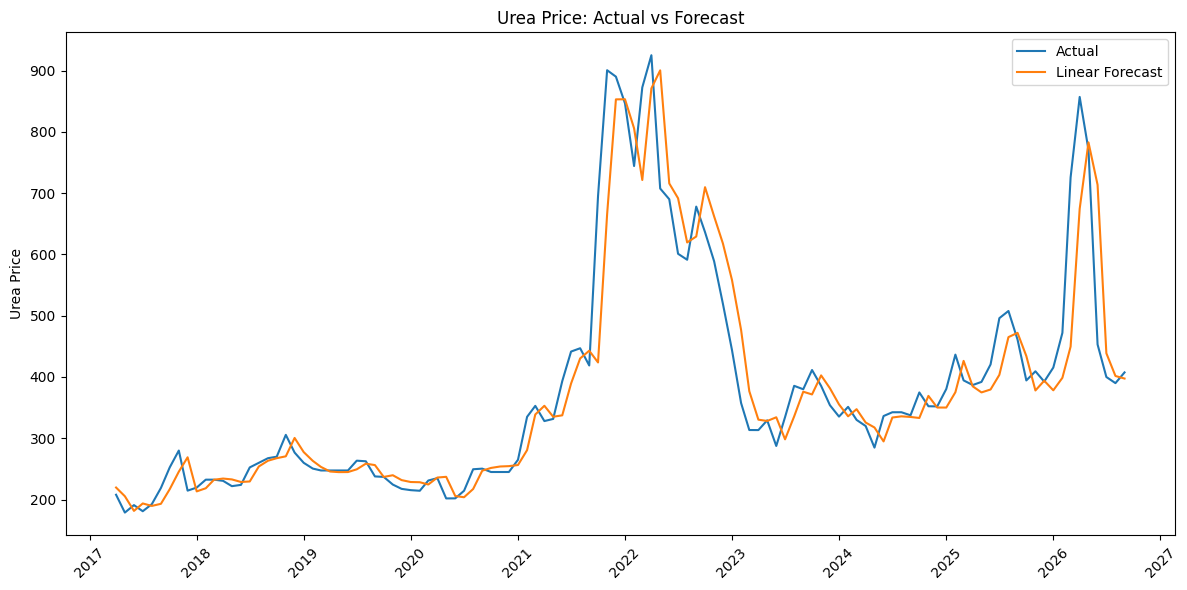

In [34]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=forecast_df,
    x="Date",
    y="Urea",
    label="Actual"
)


sns.lineplot(
    data=forecast_df,
    x="Date",
    y="Linear_Forecast",
    label="Linear Forecast"
)

plt.title("Urea Price: Actual vs Forecast")
plt.xlabel("")
plt.ylabel("Urea Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()